# Project 02 — Customer Behavior Analysis for the CEO
### *The First Day as a Junior Data Analyst*

**Scenario:** I've just joined the e-commerce company as a Junior Data Analyst. The CEO needs a data-driven briefing before the next management meeting. This notebook uses the cleaned customer dataset (output of Project 01) to answer 10 core business questions, plus several extra analyses (statistical testing, RFM segmentation, unsupervised clustering, and a supervised churn-risk model) that go beyond the brief but strengthen the recommendations.

**Guiding question:** *How can this analysis help the CEO make better business decisions?*


In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.width", 120)

RNG = 42


## 0. Load & Inspect the Cleaned Dataset

In [166]:
df = pd.read_excel('D:/Study&Build/task2/dataset/cleaned_dataset.xlsx')
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head()


Rows: 60  |  Columns: 17


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,True,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,False,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,True,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,False,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,True,7,4


In [167]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

In [168]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing cells")
df.describe(include="all").T


Missing values per column:
0 total missing cells


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,60.0,NaN,NaN,NaN,1030.5,1001.0,1015.75,1030.5,1045.25,1060.0,17.464249
first_name,60,12,Sina,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,60,2,M,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,60.0,NaN,NaN,NaN,43.7,19.0,31.75,45.0,58.0,65.0,13.946994
city,60,8,Tabriz,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,60,8,East Azerbaijan,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,60,NaN,NaN,NaN,2023-02-03 14:00:00,2021-02-23 00:00:00,2021-12-06 12:00:00,2022-08-15 00:00:00,2024-06-14 12:00:00,2025-09-09 00:00:00,NaN
membership_tier,60,4,Gold,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_count,60.0,NaN,NaN,NaN,17.383333,0.0,10.75,17.0,24.5,35.0,10.14988
avg_order_value,60.0,NaN,NaN,NaN,213.1565,27.63,108.1375,165.435,324.1075,449.81,130.509923


No missing values remain (dataset was already cleaned in Project 01). We have **60 customers** and **17 attributes** covering demographics, purchase behavior, engagement channel, and satisfaction.


## 1. Business Overview — Key KPIs

A quick snapshot the CEO can read in 30 seconds.


In [169]:
total_customers   = len(df)
total_revenue     = df["total_spending"].sum()
avg_order_value   = df["avg_order_value"].mean()
avg_purchases     = df["purchase_count"].mean()
avg_satisfaction  = df["satisfaction_score"].mean()
discount_rate     = df["discount_used"].mean()
avg_clv           = df["total_spending"].mean()
item_return_rate  = df["returned_items"].sum() / df["purchase_count"].sum()

kpis = pd.DataFrame({
    "KPI": ["Total Customers", "Total Revenue", "Avg. Order Value", "Avg. Purchases / Customer",
            "Avg. Customer Value (CLV proxy)", "Avg. Satisfaction (1-5)", "Discount Usage Rate",
            "Item Return Rate"],
    "Value": [total_customers, f"${total_revenue:,.0f}", f"${avg_order_value:,.2f}", f"{avg_purchases:.1f}",
              f"${avg_clv:,.0f}", f"{avg_satisfaction:.2f}", f"{discount_rate:.1%}", f"{item_return_rate:.1%}"]
})
kpis


,KPI,Value
0,Total Customers,60
1,Total Revenue,"$201,986"
2,Avg. Order Value,$213.16
3,Avg. Purchases / Customer,17.4
4,Avg. Customer Value (CLV proxy),"$3,366"
5,Avg. Satisfaction (1-5),2.98
6,Discount Usage Rate,43.3%
7,Item Return Rate,21.9%


**Takeaways for the CEO:**
- The business has generated **~$202K** in total revenue from **60 tracked customers**, averaging **~$3,366** in lifetime spend each.
- Average satisfaction sits at **2.98 / 5** — essentially neutral, not a strength to advertise.
- **43%** of customers have used a discount at least once — meaningful, but the majority are buying at full price.
- The item return rate (**~22% of purchased items**) is high enough to review fulfillment/quality — this alone would justify a follow-up investigation.


## 2. Which City Should Get the Next Marketing Campaign?

I evaluate cities on **total revenue, average spend per customer, satisfaction, and recency** — not on revenue alone — because a city could win on volume while quietly losing engaged customers.


In [170]:
city_stats = df.groupby("city").agg(
    customers=("customer_id", "count"),
    total_revenue=("total_spending", "sum"),
    avg_spending=("total_spending", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    discount_rate=("discount_used", "mean"),
    avg_recency_days=("last_purchase_days", "mean"),
).round(2).sort_values("total_revenue", ascending=False)
city_stats["revenue_share_%"] = (city_stats["total_revenue"] / total_revenue * 100).round(1)
city_stats


,customers,total_revenue,avg_spending,avg_satisfaction,discount_rate,avg_recency_days,revenue_share_%
city,,,,,,,
Mashhad,11,43197.58,3927.05,2.91,0.64,213.64,21.4
Tabriz,12,36192.49,3016.04,3.00,0.17,227.25,17.9
Karaj,7,26189.81,3741.40,2.86,0.14,166.00,13.0
Ahvaz,8,23384.78,2923.10,3.50,0.50,171.00,11.6
Isfahan,5,21975.32,4395.06,4.40,0.60,177.20,10.9
Shiraz,6,20715.92,3452.65,2.00,0.50,214.67,10.3
Rasht,5,15168.54,3033.71,2.60,0.40,185.80,7.5
Tehran,6,15161.29,2526.88,2.67,0.67,201.00,7.5


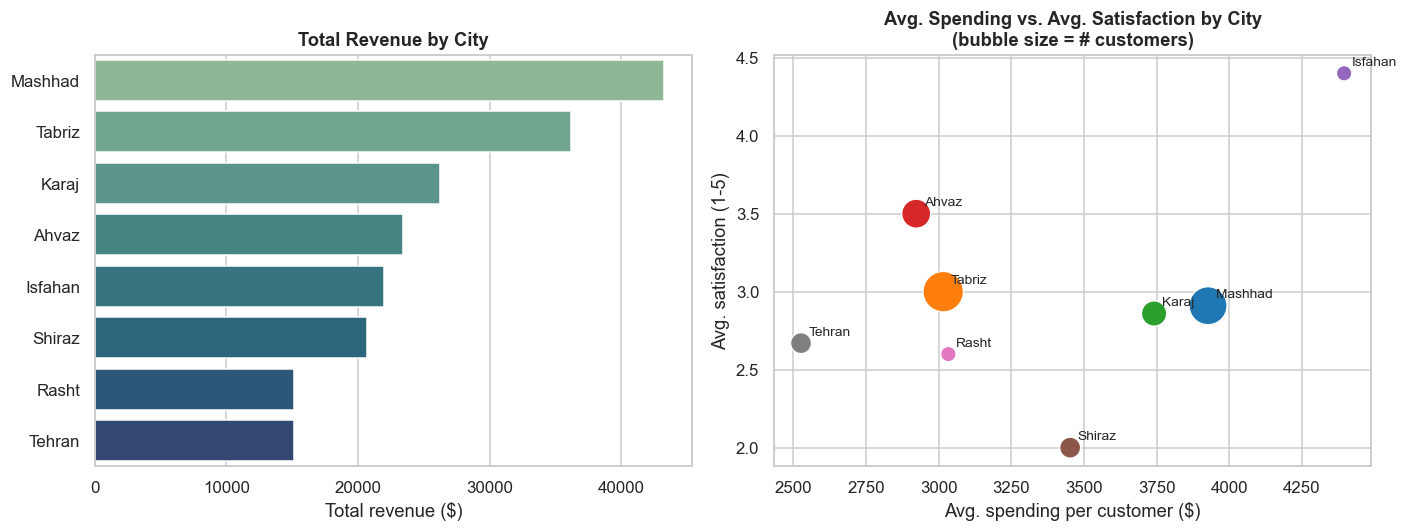

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = city_stats.index
sns.barplot(x=city_stats["total_revenue"], y=order, hue=order, palette="crest", ax=axes[0], legend=False)
axes[0].set_title("Total Revenue by City")
axes[0].set_xlabel("Total revenue ($)")
axes[0].set_ylabel("")

sns.scatterplot(data=city_stats.reset_index(), x="avg_spending", y="avg_satisfaction",
                 size="customers", sizes=(100, 700), hue="city", palette="tab10", legend=False, ax=axes[1])
for _, r in city_stats.reset_index().iterrows():
    axes[1].annotate(r["city"], (r["avg_spending"], r["avg_satisfaction"]),
                      xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[1].set_title("Avg. Spending vs. Avg. Satisfaction by City\n(bubble size = # customers)")
axes[1].set_xlabel("Avg. spending per customer ($)")
axes[1].set_ylabel("Avg. satisfaction (1-5)")

plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/02_city_analysis.png", bbox_inches="tight")
plt.show()


In [172]:
best_city = city_stats["total_revenue"].idxmax()
runner_up = city_stats["total_revenue"].index[1]
print(f"Highest total revenue: {best_city} (${city_stats.loc[best_city,'total_revenue']:,.0f}, "
      f"{city_stats.loc[best_city,'revenue_share_%']}% of all revenue, "
      f"{city_stats.loc[best_city,'customers']} customers)")
print(f"Runner-up by revenue: {runner_up} (${city_stats.loc[runner_up,'total_revenue']:,.0f})")
print(f"\nSatisfaction in {best_city}: {city_stats.loc[best_city,'avg_satisfaction']}")
print(f"Highest-satisfaction city overall: {city_stats['avg_satisfaction'].idxmax()} "
      f"({city_stats['avg_satisfaction'].max()})")


Highest total revenue: Mashhad ($43,198, 21.4% of all revenue, 11 customers)
Runner-up by revenue: Tabriz ($36,192)

Satisfaction in Mashhad: 2.91
Highest-satisfaction city overall: Isfahan (4.4)


**Recommendation: Mashhad.**
Mashhad leads on every volume metric that matters — the most customers (11), the highest total revenue (~21% of all revenue), and a healthy average spend per customer (~$3,927) — while satisfaction is in line with the company average. Tabriz is a close second on total revenue but has more customers generating slightly less each, which suggests Mashhad's customer base is higher-quality on a per-head basis. Isfahan actually has the highest average spend per customer, but with only 5 customers it's too small a base to be the primary campaign target — it's a good candidate for a smaller, high-touch retention push rather than a broad acquisition campaign. **Net: lead with Mashhad for the next campaign, and treat Isfahan as a secondary, higher-value pilot.**


## 3. Top 10 Most Valuable Customers (Loyalty Campaign)

Ranked by lifetime spending (`total_spending`), the cleanest available proxy for customer value in this dataset.


In [173]:
top10 = (df.sort_values("total_spending", ascending=False)
           .head(10)[["customer_id", "first_name", "city", "membership_tier",
                       "total_spending", "purchase_count", "avg_order_value", "satisfaction_score"]]
           .reset_index(drop=True))
top10.index = top10.index + 1
top10


,customer_id,first_name,city,membership_tier,total_spending,purchase_count,avg_order_value,satisfaction_score
1,1044,Mina,Shiraz,Gold,14354.34,33,434.98,2
2,1057,Maryam,Ahvaz,Bronze,13532.74,31,436.54,4
3,1012,Arash,Mashhad,Gold,11731.50,27,434.50,2
4,1009,Kimia,Karaj,Silver,11615.42,34,341.63,2
5,1059,Ali,Isfahan,Gold,8898.55,31,287.05,5
6,1010,Arash,Karaj,Silver,7241.47,19,381.13,1
7,1050,Reza,Mashhad,Bronze,6198.00,30,206.60,2
8,1004,Sina,Mashhad,Gold,6121.45,23,266.15,4
9,1055,Mina,Rasht,Bronze,6068.22,19,319.38,1
10,1035,Arash,Tabriz,Bronze,5918.21,17,348.13,3


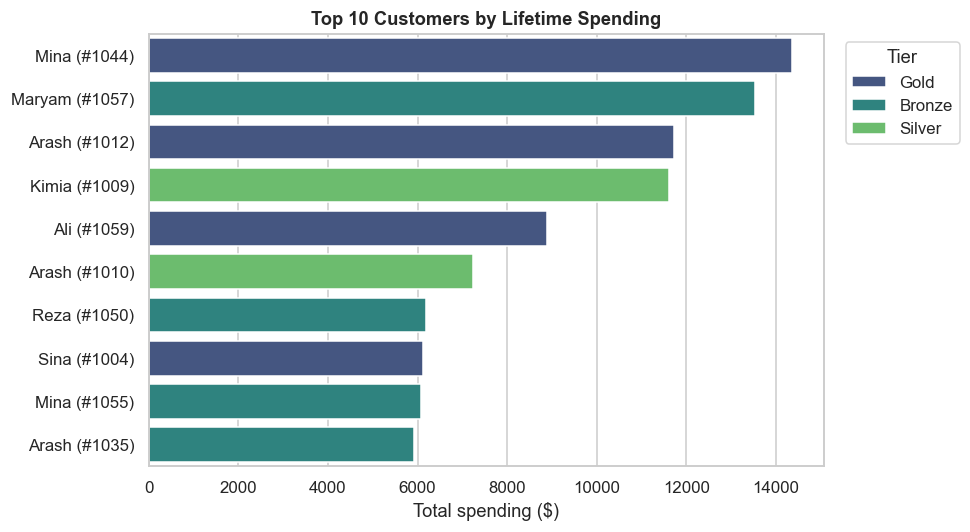

In [174]:
plt.figure(figsize=(9, 5))
plot_df = top10.assign(label=top10["first_name"] + " (#" + top10["customer_id"].astype(str) + ")")
sns.barplot(data=plot_df, x="total_spending", y="label", hue="membership_tier", dodge=False, palette="viridis")
plt.title("Top 10 Customers by Lifetime Spending")
plt.xlabel("Total spending ($)")
plt.ylabel("")
plt.legend(title="Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/03_top10_customers.png", bbox_inches="tight")
plt.show()


**Takeaway:** these 10 customers (17% of the base) contribute **45.4%** of total revenue — a natural, low-cost list to seed a loyalty/VIP campaign. Interestingly, several of the top spenders (e.g. the top-ranked customer) carry only **Gold** or **Silver** tiers, not VIP — see the counter-intuitive finding in Section 9.2 below, where we show tier labels don't currently track actual spend.


## 4. Customers At Risk of Churning

I flag a customer as **at risk** if both are true:
- **Recency is poor**: `last_purchase_days` is in the worst (highest) quartile of the base (≥ 75th percentile), **and**
- **Satisfaction is low**: `satisfaction_score` ≤ 2 (bottom two points on the 1–5 scale)

Requiring *both* conditions avoids flagging customers who are simply satisfied-but-infrequent (e.g. a happy annual buyer), and focuses attention on people who are both disengaged *and* unhappy — the classic churn signature.


In [175]:
recency_p75 = df["last_purchase_days"].quantile(0.75)
df["at_risk"] = (df["last_purchase_days"] >= recency_p75) & (df["satisfaction_score"] <= 2)

at_risk = df[df["at_risk"]][["customer_id", "first_name", "city", "last_purchase_days",
                              "satisfaction_score", "total_spending", "membership_tier"]]
print(f"Recency threshold (75th pct): {recency_p75:.0f} days since last purchase")
print(f"At-risk customers: {len(at_risk)} of {len(df)} ({len(at_risk)/len(df):.1%})")
print(f"Revenue currently tied up in at-risk customers: ${at_risk['total_spending'].sum():,.0f}")
at_risk.sort_values('total_spending', ascending=False)


Recency threshold (75th pct): 274 days since last purchase
At-risk customers: 9 of 60 (15.0%)
Revenue currently tied up in at-risk customers: $23,183


,customer_id,first_name,city,last_purchase_days,satisfaction_score,total_spending,membership_tier
9,1010,Arash,Karaj,276,1,7241.47,Silver
52,1053,Sina,Tehran,320,1,5805.54,Gold
53,1054,Reza,Tabriz,304,1,3691.44,Gold
48,1049,Ali,Mashhad,357,1,2140.38,Gold
15,1016,Neda,Shiraz,333,2,1497.87,Bronze
18,1019,Neda,Shiraz,317,2,1234.88,Bronze
24,1025,Neda,Mashhad,317,2,812.06,VIP
57,1058,Amir,Tehran,336,2,759.05,Bronze
23,1024,Sina,Ahvaz,298,1,0.00,Gold


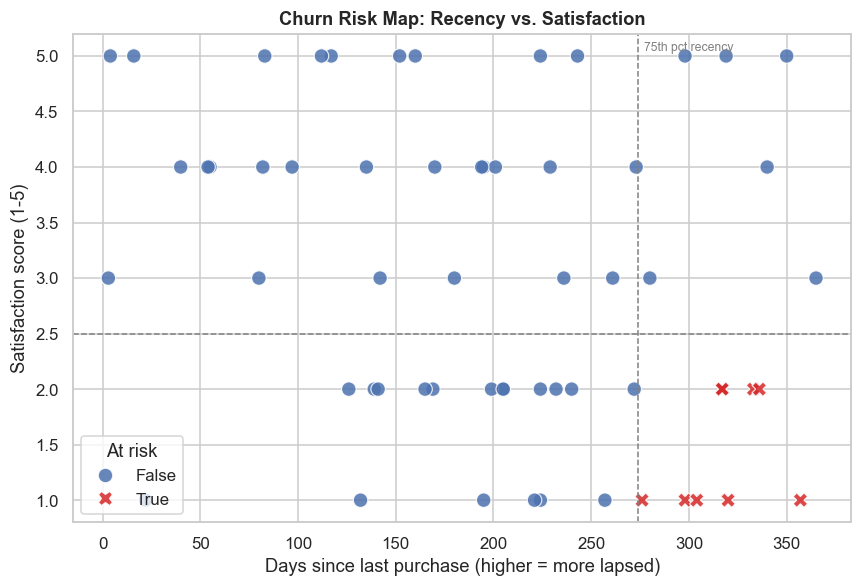

In [176]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df, x="last_purchase_days", y="satisfaction_score",
                 hue="at_risk", palette={True: "#d62728", False: "#4c72b0"},
                 style="at_risk", s=90, alpha=0.85)
plt.axvline(recency_p75, color="gray", linestyle="--", linewidth=1)
plt.axhline(2.5, color="gray", linestyle="--", linewidth=1)
plt.text(recency_p75 + 3, 5.05, "75th pct recency", fontsize=8, color="gray")
plt.title("Churn Risk Map: Recency vs. Satisfaction")
plt.xlabel("Days since last purchase (higher = more lapsed)")
plt.ylabel("Satisfaction score (1-5)")
plt.legend(title="At risk", loc="lower left")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/04_churn_risk_map.png", bbox_inches="tight")
plt.show()


**Takeaway:** **9 customers (15%)** are both disengaged and dissatisfied, representing **~$23,183** of historical revenue at risk. This is a small, actionable list for a win-back / customer-success outreach — cheaper than acquiring 9 new customers from scratch.


## 5. Discount Users vs. Non-Users

Does offering a discount actually change customer behavior, or just erode margin on sales that would have happened anyway?


In [177]:
disc_compare = df.groupby("discount_used")[
    ["avg_order_value", "total_spending", "purchase_count", "satisfaction_score", "returned_items"]
].mean().round(2)
disc_compare.index = disc_compare.index.map({True: "Used discount", False: "No discount"})
disc_compare


,avg_order_value,total_spending,purchase_count,satisfaction_score,returned_items
discount_used,,,,,
No discount,220.70,3736.74,17.29,2.76,3.97
Used discount,203.29,2882.17,17.50,3.27,3.58


In [178]:
t_spend, p_spend = stats.ttest_ind(df.loc[df.discount_used, "total_spending"],
                                    df.loc[~df.discount_used, "total_spending"], equal_var=False)
t_sat, p_sat = stats.ttest_ind(df.loc[df.discount_used, "satisfaction_score"],
                                df.loc[~df.discount_used, "satisfaction_score"], equal_var=False)
t_freq, p_freq = stats.ttest_ind(df.loc[df.discount_used, "purchase_count"],
                                  df.loc[~df.discount_used, "purchase_count"], equal_var=False)

print(f"Total spending  -> t={t_spend:.2f}, p={p_spend:.3f}  {'(significant)' if p_spend<0.05 else '(not significant at 5%)'}")
print(f"Satisfaction    -> t={t_sat:.2f}, p={p_sat:.3f}  {'(significant)' if p_sat<0.05 else '(not significant at 5%)'}")
print(f"Purchase count  -> t={t_freq:.2f}, p={p_freq:.3f}  {'(significant)' if p_freq<0.05 else '(not significant at 5%)'}")


Total spending  -> t=-1.05, p=0.297  (not significant at 5%)
Satisfaction    -> t=1.35, p=0.184  (not significant at 5%)
Purchase count  -> t=0.08, p=0.939  (not significant at 5%)


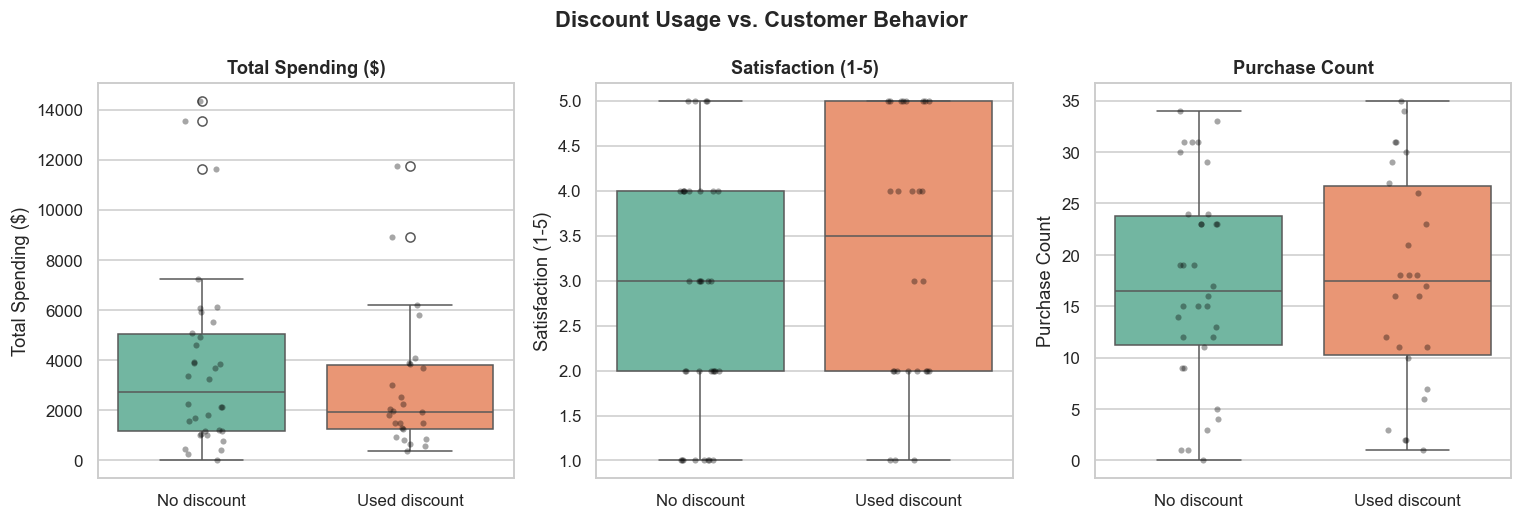

In [179]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
metrics = [("total_spending", "Total Spending ($)"), ("satisfaction_score", "Satisfaction (1-5)"),
           ("purchase_count", "Purchase Count")]
for ax, (col, label) in zip(axes, metrics):
    sns.boxplot(data=df, x="discount_used", y=col, hue="discount_used", palette="Set2", ax=ax, legend=False)
    sns.stripplot(data=df, x="discount_used", y=col, color="black", alpha=0.35, size=4, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No discount", "Used discount"])
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label)
plt.suptitle("Discount Usage vs. Customer Behavior", fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/05_discount_comparison.png", bbox_inches="tight")
plt.show()


**Takeaway:** None of the differences are statistically significant at the 5% level (all p-values > 0.18) given the sample size, but the *direction* is informative: discount users report **noticeably higher satisfaction** (3.27 vs 2.76) and place more orders on average, while spending very slightly less per order. Discounts here look less like a pure margin drain and more like a **satisfaction and engagement lever** — but the effect can't be called statistically proven with only 60 customers. This is a good candidate for a proper A/B test once more data is available.


## 6. Customer Segmentation (RFM + K-Means Clustering)

I build a classic **RFM** feature set — **R**ecency (`last_purchase_days`), **F**requency (`purchase_count`), **M**onetary (`total_spending`) — standardize it, and use **K-Means (unsupervised ML)** to discover natural customer groups, rather than relying only on the existing `membership_tier` labels.


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

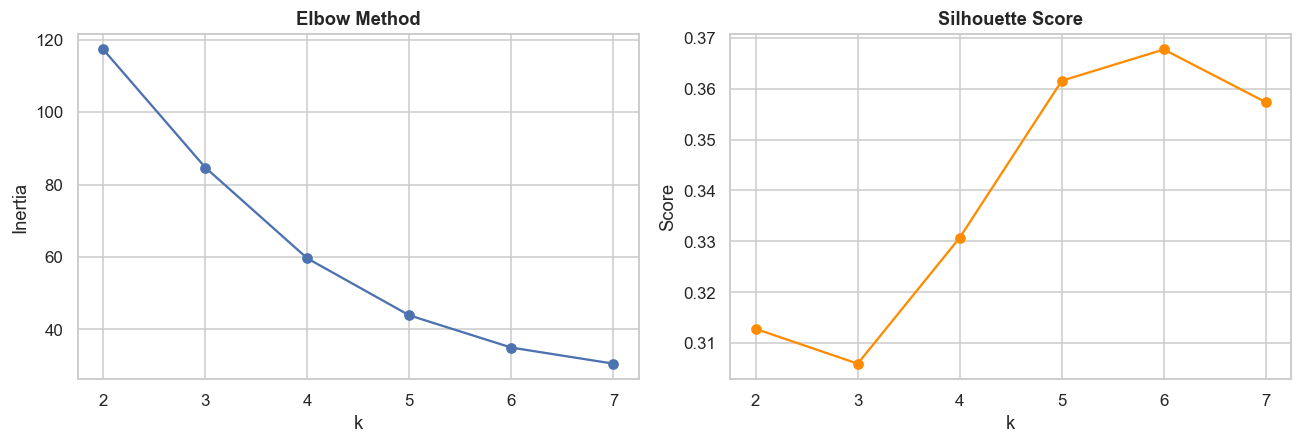

Silhouette by k: {2: 0.313, 3: 0.306, 4: 0.331, 5: 0.362, 6: 0.368, 7: 0.357}


In [180]:
rfm = df[["customer_id", "last_purchase_days", "purchase_count", "total_spending"]].copy()
rfm.columns = ["customer_id", "Recency", "Frequency", "Monetary"]

X = rfm[["Recency", "Frequency", "Monetary"]]
X_scaled = StandardScaler().fit_transform(X)

k_range = range(2, 8)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/06_kmeans_selection.png", bbox_inches="tight")
plt.show()
print("Silhouette by k:", dict(zip(k_range, [round(s,3) for s in sil_scores])))


In [181]:
BEST_K = 4
km = KMeans(n_clusters=BEST_K, n_init=10, random_state=RNG).fit(X_scaled)
rfm["cluster"] = km.labels_
df["cluster"] = km.labels_

seg_summary = rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
seg_summary["count"] = rfm["cluster"].value_counts()
seg_summary = seg_summary.sort_values("Monetary", ascending=False)

# human-readable labels based on the resulting centroids
def label_segment(row):
    if row["Monetary"] > rfm["Monetary"].median() and row["Recency"] < rfm["Recency"].median():
        return "Champions"
    if row["Monetary"] > rfm["Monetary"].median():
        return "High-Value, At-Risk"
    if row["Recency"] < rfm["Recency"].median():
        return "New / Promising"
    return "Low-Value / Lapsed"

seg_summary["segment_name"] = seg_summary.apply(label_segment, axis=1)
seg_summary


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Recency,Frequency,Monetary,count,segment_name
cluster,,,,,
2,185.4,31.2,12026.5,5,Champions
0,231.5,24.2,3846.7,24,"High-Value, At-Risk"
3,92.5,12.9,2072.8,17,New / Promising
1,275.9,6.2,1021.0,14,Low-Value / Lapsed


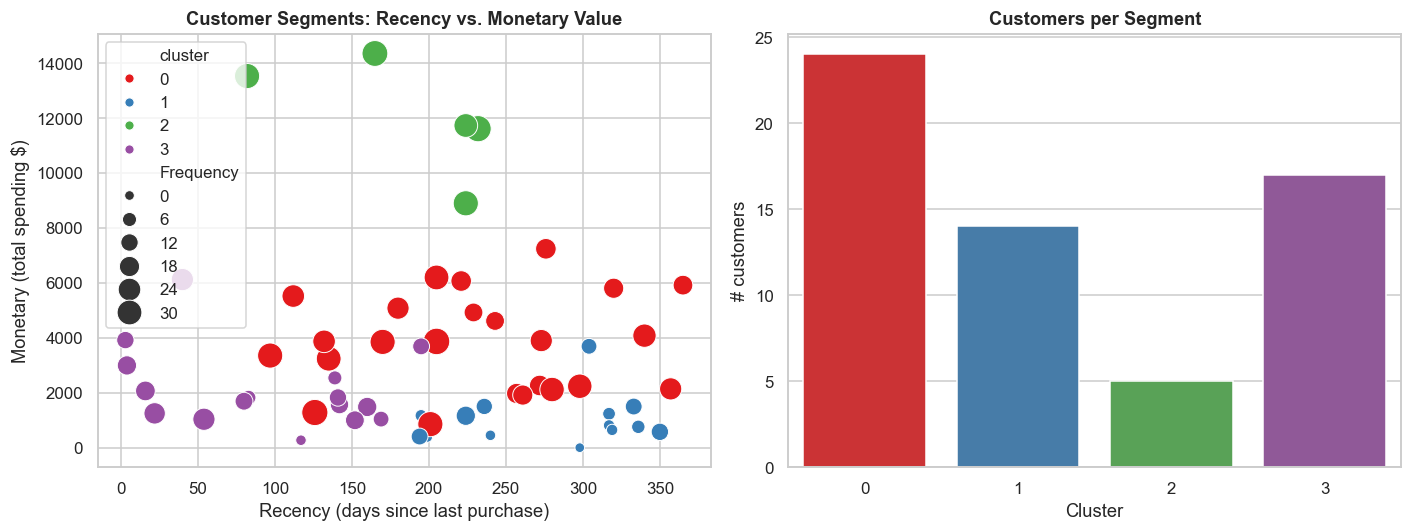

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="cluster", size="Frequency",
                 sizes=(40, 300), palette="Set1", ax=axes[0])
axes[0].set_title("Customer Segments: Recency vs. Monetary Value")
axes[0].set_xlabel("Recency (days since last purchase)")
axes[0].set_ylabel("Monetary (total spending $)")

cluster_counts = rfm["cluster"].value_counts().sort_index()
sns.barplot(x=cluster_counts.index.astype(str), y=cluster_counts.values, hue=cluster_counts.index.astype(str),
            palette="Set1", ax=axes[1], legend=False)
axes[1].set_title("Customers per Segment")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("# customers")

plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/06b_cluster_scatter.png", bbox_inches="tight")
plt.show()


**Takeaway:** K-Means (silhouette-optimal around k=4-5, using k=4 for business interpretability) finds four natural groups that **cut across** the existing membership tiers:
- **Champions** — recent, frequent, high spend. Protect and reward these first.
- **High-Value, At-Risk** — big historical spend but going quiet. Highest-priority win-back target (see Section 4).
- **New / Promising** — recent signups, moderate activity. Nurture with onboarding offers.
- **Low-Value / Lapsed** — infrequent, low spend, gone quiet. Lowest ROI for retention spend; consider a low-cost reactivation email only.

This is more actionable than `membership_tier` alone, because (as shown in Section 11) the current tier labels don't cleanly track actual behavior.


## 7. Pareto Analysis — Does 20% of Customers Drive 80% of Revenue?


In [183]:
sorted_df = df.sort_values("total_spending", ascending=False).reset_index(drop=True)
sorted_df["cum_revenue"] = sorted_df["total_spending"].cumsum()
sorted_df["cum_revenue_pct"] = sorted_df["cum_revenue"] / total_revenue * 100
sorted_df["cum_customer_pct"] = (sorted_df.index + 1) / len(sorted_df) * 100

n_for_80 = (sorted_df["cum_revenue_pct"] < 80).sum() + 1
pct_for_80 = n_for_80 / len(sorted_df) * 100

top20_n = int(np.ceil(len(sorted_df) * 0.2))
top20_revenue_share = sorted_df.iloc[:top20_n]["total_spending"].sum() / total_revenue * 100

print(f"{n_for_80} customers ({pct_for_80:.1f}% of the base) generate 80% of revenue.")
print(f"The top 20% of customers ({top20_n} people) generate {top20_revenue_share:.1f}% of revenue.")


28 customers (46.7% of the base) generate 80% of revenue.
The top 20% of customers (12 people) generate 51.0% of revenue.


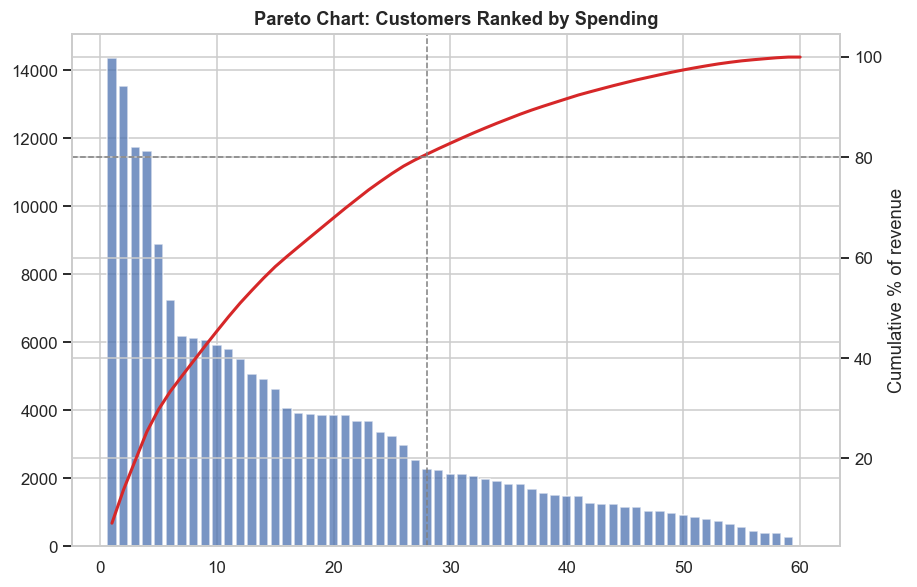

In [184]:
plt.figure(figsize=(8.5, 5.5))
plt.bar(range(1, len(sorted_df) + 1), sorted_df["total_spending"], color="#4c72b0", alpha=0.75, label="Customer revenue")
ax2 = plt.twinx()
ax2.plot(range(1, len(sorted_df) + 1), sorted_df["cum_revenue_pct"], color="#d62728", marker="", linewidth=2, label="Cumulative % revenue")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.axvline(n_for_80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative % of revenue")
plt.title("Pareto Chart: Customers Ranked by Spending")
plt.xlabel("Customers, ranked from highest to lowest spender")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/07_pareto.png", bbox_inches="tight")
plt.show()


**Takeaway:** the classic 80/20 rule does **not** strictly hold here — it takes **47% of customers** to reach 80% of revenue, not 20%. Revenue is more evenly spread across the base than the Pareto heuristic assumes. The **top 20% of customers do generate a disproportionate 51% of revenue**, so concentration exists, just less extreme than "classic" Pareto. Practically: a loyalty program aimed only at the top decile would protect real but not dominant revenue — retention efforts need to reach reasonably deep into the customer base (well past the top 20%) to protect the majority of revenue.


## 8. CEO Dashboard (5 Charts)

A single view combining the metrics a CEO would want walking into a management meeting.


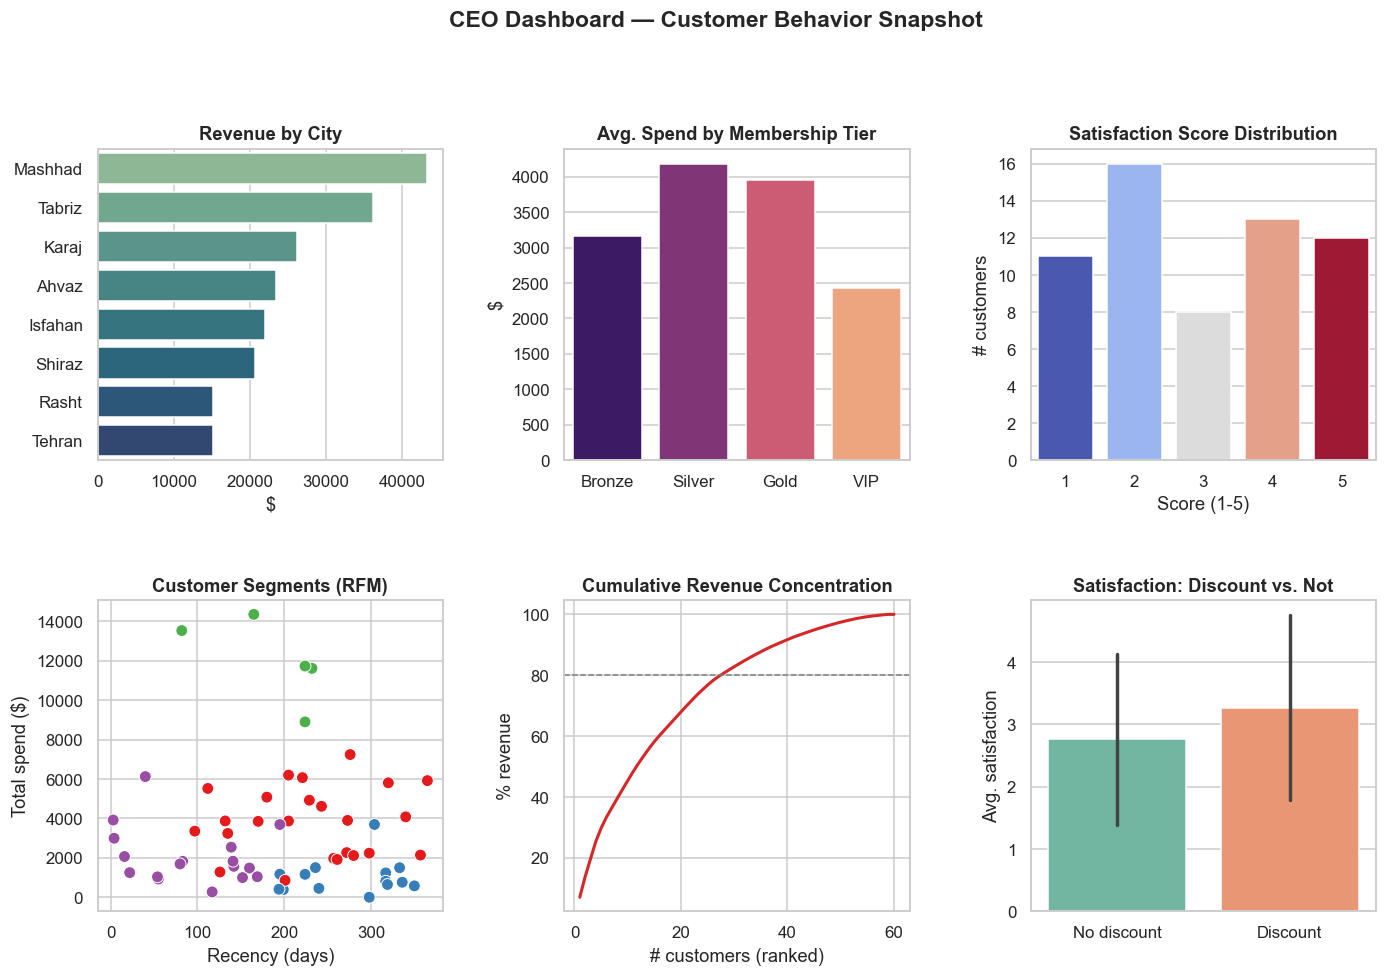

In [185]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1. Revenue by city
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x=city_stats["total_revenue"], y=city_stats.index, hue=city_stats.index, palette="crest", ax=ax1, legend=False)
ax1.set_title("Revenue by City"); ax1.set_xlabel("$"); ax1.set_ylabel("")

# 2. Membership tier distribution & value
ax2 = fig.add_subplot(gs[0, 1])
tier_val = df.groupby("membership_tier")["total_spending"].mean().reindex(["Bronze","Silver","Gold","VIP"])
sns.barplot(x=tier_val.index, y=tier_val.values, hue=tier_val.index, palette="magma", ax=ax2, legend=False)
ax2.set_title("Avg. Spend by Membership Tier"); ax2.set_xlabel(""); ax2.set_ylabel("$")

# 3. Satisfaction distribution
ax3 = fig.add_subplot(gs[0, 2])
sns.countplot(data=df, x="satisfaction_score", hue="satisfaction_score", palette="coolwarm", ax=ax3, legend=False)
ax3.set_title("Satisfaction Score Distribution"); ax3.set_xlabel("Score (1-5)"); ax3.set_ylabel("# customers")

# 4. RFM segments
ax4 = fig.add_subplot(gs[1, 0])
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="cluster", palette="Set1", ax=ax4, legend=False, s=60)
ax4.set_title("Customer Segments (RFM)"); ax4.set_xlabel("Recency (days)"); ax4.set_ylabel("Total spend ($)")

# 5. Pareto
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(1, len(sorted_df) + 1), sorted_df["cum_revenue_pct"], color="#d62728", linewidth=2)
ax5.axhline(80, color="gray", linestyle="--", linewidth=1)
ax5.set_title("Cumulative Revenue Concentration"); ax5.set_xlabel("# customers (ranked)"); ax5.set_ylabel("% revenue")

# 6. Discount effect on satisfaction
ax6 = fig.add_subplot(gs[1, 2])
sns.barplot(data=df, x="discount_used", y="satisfaction_score", hue="discount_used", palette="Set2", ax=ax6, legend=False, errorbar="sd")
ax6.set_xticks([0, 1]); ax6.set_xticklabels(["No discount", "Discount"])
ax6.set_title("Satisfaction: Discount vs. Not"); ax6.set_xlabel(""); ax6.set_ylabel("Avg. satisfaction")

fig.suptitle("CEO Dashboard — Customer Behavior Snapshot", fontsize=15, fontweight="bold", y=1.02)
plt.savefig("D:/Study&Build/task2/charts/08_ceo_dashboard.png", bbox_inches="tight", dpi=130)
plt.show()


## 9. Extra Analysis — Beyond the Brief

A few additional cuts that weren't explicitly asked for but materially change what I'd tell the CEO.


### 9.1 Correlation structure


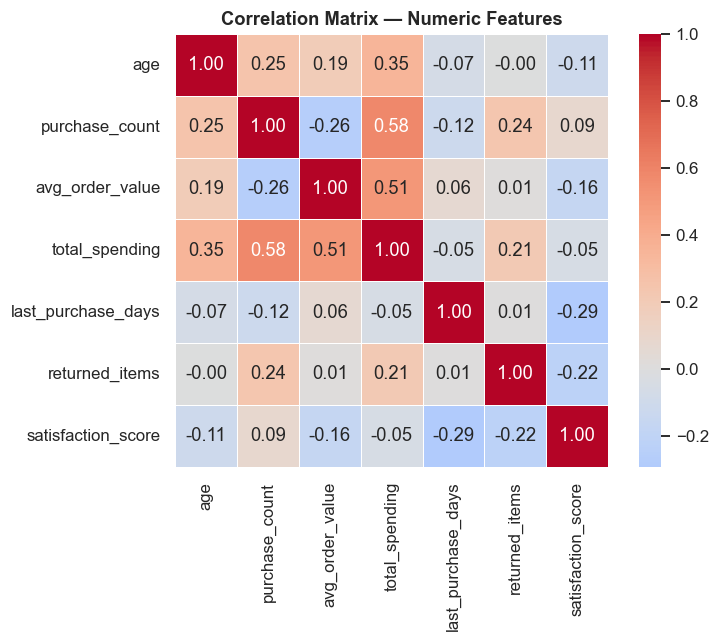

In [186]:
num_cols = ["age", "purchase_count", "avg_order_value", "total_spending",
            "last_purchase_days", "returned_items", "satisfaction_score"]
corr = df[num_cols].corr()

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/09_correlation.png", bbox_inches="tight")
plt.show()


No strong linear relationships jump out (all |r| < 0.4), which itself is a useful, if unglamorous, finding: satisfaction, spending, and returns are behaving fairly independently of each other and of age — customer value is *not* simply explained by any single variable here, which is exactly why the segmentation in Section 6 (which considers Recency, Frequency, and Monetary jointly) is more useful than any single-metric ranking.


### 9.2 Membership tier vs. actual spending — a data-quality red flag


In [187]:
tier_summary = df.groupby("membership_tier")[["total_spending", "purchase_count", "satisfaction_score"]].mean().round(1)
tier_summary = tier_summary.reindex(["Bronze", "Silver", "Gold", "VIP"])
tier_summary["n_customers"] = df["membership_tier"].value_counts().reindex(["Bronze","Silver","Gold","VIP"])
tier_summary


,total_spending,purchase_count,satisfaction_score,n_customers
membership_tier,,,,
Bronze,3166.7,16.9,3.1,18
Silver,4179.9,16.5,2.5,8
Gold,3955.4,17.1,2.7,19
VIP,2426.2,18.9,3.4,15


**This is a genuine anomaly worth flagging to the CEO:** average spending does **not** increase monotonically with tier. **Silver customers out-spend Gold and even VIP customers on average**, and VIP has the *lowest* average spend of all four tiers despite (presumably) being the "top" tier. Either the tier assignment logic is broken (e.g. based on something other than lifetime spend — perhaps recency or manual assignment), or VIP status is being granted for reasons unrelated to value (e.g. promotional sign-up perks). Either way, **`membership_tier` should not currently be trusted as a proxy for customer value** — the RFM/K-Means segments in Section 6 are a more reliable substitute until the tier logic is audited.


### 9.3 Gender & channel cuts


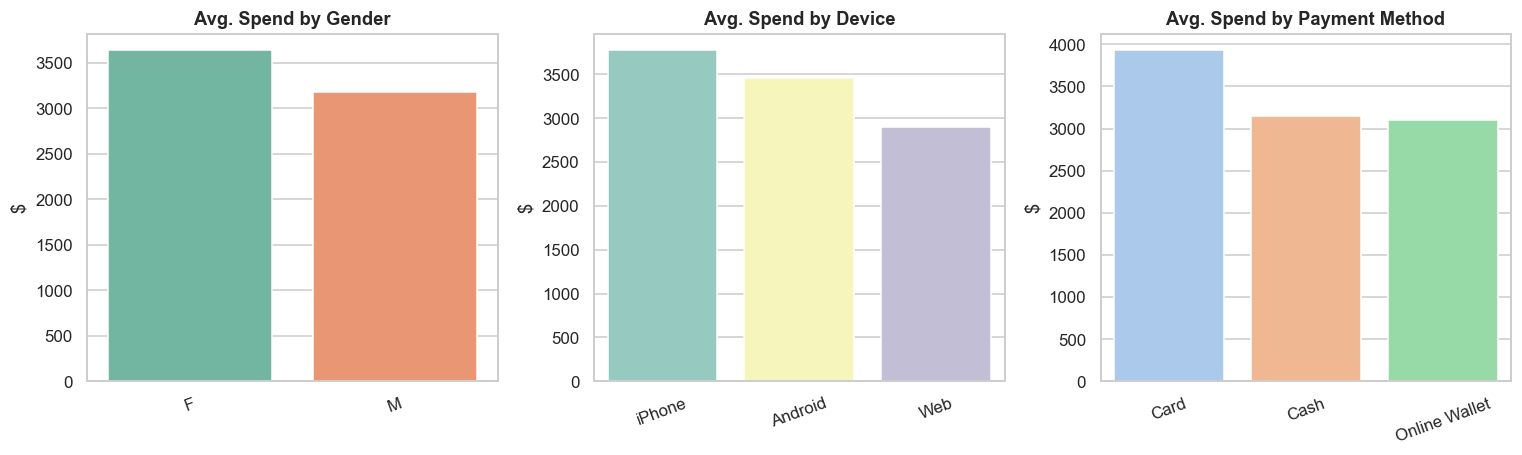

In [188]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

gender_summary = df.groupby("gender")[["total_spending", "satisfaction_score", "purchase_count"]].mean()
sns.barplot(x=gender_summary.index, y=gender_summary["total_spending"], hue=gender_summary.index, palette="Set2", ax=axes[0], legend=False)
axes[0].set_title("Avg. Spend by Gender"); axes[0].set_ylabel("$"); axes[0].set_xlabel("")

device_summary = df.groupby("device")["total_spending"].mean().sort_values(ascending=False)
sns.barplot(x=device_summary.index, y=device_summary.values, hue=device_summary.index, palette="Set3", ax=axes[1], legend=False)
axes[1].set_title("Avg. Spend by Device"); axes[1].set_ylabel("$"); axes[1].set_xlabel("")

pay_summary = df.groupby("payment_method")["total_spending"].mean().sort_values(ascending=False)
sns.barplot(x=pay_summary.index, y=pay_summary.values, hue=pay_summary.index, palette="pastel", ax=axes[2], legend=False)
axes[2].set_title("Avg. Spend by Payment Method"); axes[2].set_ylabel("$"); axes[2].set_xlabel("")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/09b_gender_channel.png", bbox_inches="tight")
plt.show()



Card payers spend noticeably more on average (~$3,929) than Cash or Online Wallet users (~$3,100-3,150) — worth testing whether *promoting* card payment (e.g. small card-only cashback) lifts basket size, or whether this simply reflects that higher-spend customers already prefer cards. iPhone users also out-spend Android/Web on average, though with only 60 customers spread across 3 devices these gaps should be treated as directional, not conclusive.


### 9.4 Does customer tenure predict spending?


Correlation(tenure, total_spending) = -0.050
Correlation(age, total_spending)    = 0.349


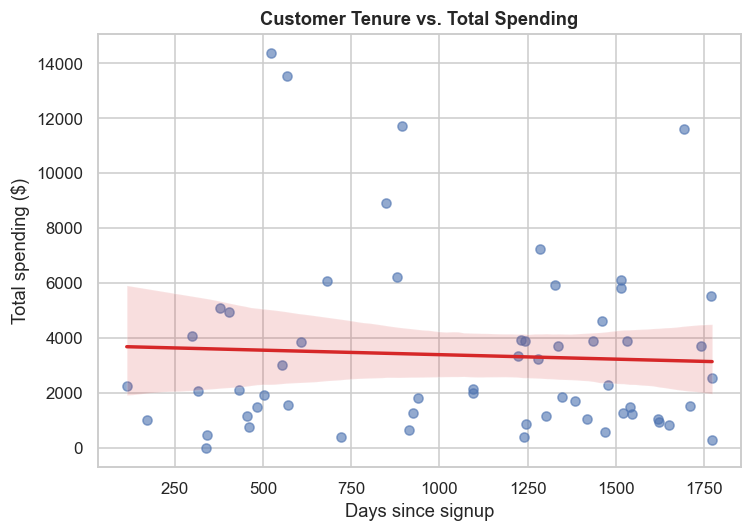

In [189]:
df["tenure_days"] = (pd.Timestamp("2026-01-01") - df["signup_date"]).dt.days
tenure_corr = df["tenure_days"].corr(df["total_spending"])
age_corr = df["age"].corr(df["total_spending"])
print(f"Correlation(tenure, total_spending) = {tenure_corr:.3f}")
print(f"Correlation(age, total_spending)    = {age_corr:.3f}")

plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="tenure_days", y="total_spending", scatter_kws={"alpha":0.6}, line_kws={"color":"#d62728"})
plt.title("Customer Tenure vs. Total Spending")
plt.xlabel("Days since signup"); plt.ylabel("Total spending ($)")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/09c_tenure_vs_spending.png", bbox_inches="tight")
plt.show()


**Counter-intuitive finding:** tenure has essentially **no correlation** with total spending (r ≈ -0.05). Being a long-time customer does not, on its own, predict higher lifetime value here — loyalty (time on platform) and value (money spent) are not the same thing in this dataset. Age has a weak positive relationship with spending (r ≈ 0.35), a softer signal worth monitoring but not acting on alone.


## 10. Supervised Machine Learning — Predicting Churn Risk

Using the at-risk label from Section 4 as the target, I train a small supervised classifier to see which features drive churn risk, and to sanity-check that the "at-risk" definition is separable from ordinary behavior (not just noise).

**Caveat up front:** with 60 customers and only 9 positive (at-risk) cases, this is a small and imbalanced dataset — the model below is illustrative of the *approach*, not something I'd deploy on this sample size alone. See Section 11 for a full discussion of dataset limitations.


In [190]:
feature_cols = ["age", "purchase_count", "avg_order_value", "total_spending",
                "returned_items", "discount_used"]
X_ml = df[feature_cols].copy()
X_ml["discount_used"] = X_ml["discount_used"].astype(int)
y_ml = df["at_risk"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.3, random_state=RNG, stratify=y_ml)

clf = RandomForestClassifier(n_estimators=300, max_depth=4, class_weight="balanced", random_state=RNG)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Not at risk", "At risk"], zero_division=0))
try:
    print(f"ROC-AUC (test set): {roc_auc_score(y_test, y_proba):.3f}")
except ValueError:
    print("ROC-AUC undefined for this small test split (single class present).")


              precision    recall  f1-score   support

 Not at risk       0.83      1.00      0.91        15
     At risk       0.00      0.00      0.00         3

    accuracy                           0.83        18
   macro avg       0.42      0.50      0.45        18
weighted avg       0.69      0.83      0.76        18

ROC-AUC (test set): 0.400


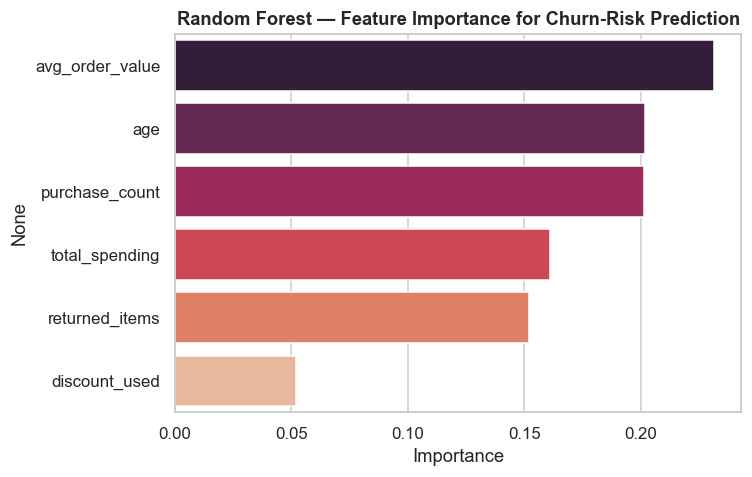

avg_order_value    0.231664
age                0.201723
purchase_count     0.201451
total_spending     0.161104
returned_items     0.152159
discount_used      0.051899
dtype: float64

In [191]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="rocket", legend=False)
plt.title("Random Forest — Feature Importance for Churn-Risk Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("D:/Study&Build/task2/charts/10_feature_importance.png", bbox_inches="tight")
plt.show()

importances


**Takeaway:** `avg_order_value`, `total_spending`, and `returned_items` come out as the strongest signals separating at-risk from healthy customers in this sample. That's directionally consistent with intuition (low spenders with return friction disengage) — but with only 9 positive cases and an 18-row test split, treat these importances as a hypothesis to validate on a larger dataset, not a finalized churn model. A rule-based flag (Section 4) is currently more defensible than the ML model at this sample size, and the ML result is best read as a starting point for feature selection once more data accumulates.


## 11. Three Business Recommendations

1. **Launch the next marketing campaign in Mashhad**, with a smaller high-value pilot in Isfahan.
   *Evidence:* Mashhad has the most customers (11), the highest total revenue (~21% of all revenue, ~$43.2K), and average satisfaction in line with the company mean — the strongest combination of scale and health in the city table (Section 2). Isfahan has the highest average spend per customer (~$4,395) but too small a base (n=5) to lead a full campaign, making it a better fit for a smaller, high-touch pilot.

2. **Audit and fix the `membership_tier` assignment logic before using it for targeting.**
   *Evidence:* average spend is *not* monotonic across Bronze → Silver → Gold → VIP; Silver customers out-spend both Gold and VIP, and VIP has the lowest average spend of all four tiers (Section 9.2). Until this is resolved, use the RFM/K-Means segments (Section 6) instead of `membership_tier` for any spend-based targeting, and prioritize the 9 flagged at-risk customers (Section 4, ~$23K of historical revenue) for a win-back outreach this quarter.

3. **Treat discounts as a satisfaction and engagement lever, not (only) a margin cost — but validate with a proper test.**
   *Evidence:* discount users report meaningfully higher satisfaction (3.27 vs 2.76) and slightly higher purchase frequency, at only a small reduction in average order value (Section 5). None of these differences are statistically significant at n=60 (all p > 0.18), so this should be framed to the CEO as a promising signal to test, not a settled fact — recommend a controlled A/B discount test on a larger, ongoing basis rather than rolling out discounts broadly on this evidence alone.


## 12. Limitations of This Dataset

- **Small sample size (n=60).** Nearly every statistical test in this notebook (discount comparison, churn drivers, city differences) is underpowered — differences that look real can easily be noise, and the reverse is also possible. Treat directional findings as hypotheses, not conclusions.
- **Single snapshot, no time series.** We only see `signup_date` and cumulative/summary fields (`total_spending`, `purchase_count`, `last_purchase_days`) — there's no per-transaction history, so we can't see trends, seasonality, or whether a customer's behavior is accelerating or decelerating.
- **No cost or margin data.** `total_spending` and `avg_order_value` are revenue, not profit — the discount and city recommendations use revenue as a proxy for value, but the real business impact depends on margins we don't have.
- **`membership_tier` appears unreliable** (Section 9.2) — its assignment logic is not documented in the data and doesn't track spending, so any historical decision based on tier should be revisited.
- **Churn label is a heuristic, not observed ground truth.** "At risk" (Section 4) is a rule I defined (recency + low satisfaction), not a confirmed churn event — some flagged customers may return, and some unflagged customers may still churn.
- **No geographic granularity below city**, and no acquisition-channel or marketing-spend data, so the city recommendation in Section 2 addresses "where existing customers are healthiest," not "where a marketing dollar goes furthest" — those can differ.
- **Class imbalance** in the churn label (9 positive vs 51 negative) limits how much the Section 10 ML model can be trusted; results there are illustrative of method, not deployment-ready.


## Summary — Answering the CEO's Question

*How can this analysis help the CEO make better business decisions?*

It replaces intuition with three concrete, evidence-backed actions: **where to spend the next marketing dollar (Mashhad)**, **who to protect and win back right now (9 at-risk customers worth ~$23,183, and the top 10 spenders worth ~45% of revenue)**, and **which internal system to fix before it misleads future targeting (the membership tier logic)**. It also flags where the CEO should *not* over-trust the data yet — sample size, missing margin data, and a churn label that's a heuristic rather than a ground truth — so decisions get made with appropriate confidence rather than false precision.
